<a href="https://colab.research.google.com/github/artuurog/Machine_Learning_LAB/blob/main/Lab_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Basic VLM usage example

Import the necessary packages

In [ ]:
import os
import base64
from openai import OpenAI
from PIL import Image
import matplotlib.pyplot as plt

The image can be either taken from the internet (copy and paste its URL) or it can be taken from the local storage (as shown in the example).

The Statue of Liberty stands proudly on a small island in New York Harbor, with the iconic Manhattan skyline and the Empire State Building visible in the background.


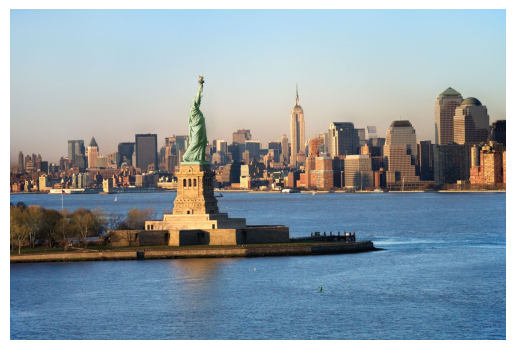

In [ ]:
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

os.environ['HF_TOKEN'] = 'your_api_key_goes_here'

client = OpenAI(
    base_url="https://router.huggingface.co/v1",
    api_key=os.environ["HF_TOKEN"],
)

# Import image
!wget -q https://cdn.britannica.com/61/93061-050-99147DCE/Statue-of-Liberty-Island-New-York-Bay.jpg -O sample.png

base64_image = encode_image("sample.png")

completion = client.chat.completions.create(
    model="allenai/Molmo2-8B",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": "Describe this image in one sentence."
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{base64_image}"
                    }
                }
            ]
        }
    ],
)

print(completion.choices[0].message.content)

# Show image
image = Image.open("sample.png")
plt.imshow(image)
plt.axis("off")
plt.show()

# MuJoCo example

Install packages

In [1]:
!pip install -q mujoco
!pip install -q mediapy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.9 MB/s eta 0:00:00


Load the model and visualize it

rm: cannot remove 'GoFa_MuJoCo_sim/': No such file or directory
Cloning into 'GoFa_MuJoCo_sim'...
remote: Enumerating objects: 120, done.
remote: Counting objects: 100% (120/120), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 120 (delta 39), reused 83 (delta 20), pack-reused 0 (from 0)
Receiving objects: 100% (120/120), 3.29 MiB | 5.94 MiB/s, done.
Resolving deltas: 100% (39/39), done.


""

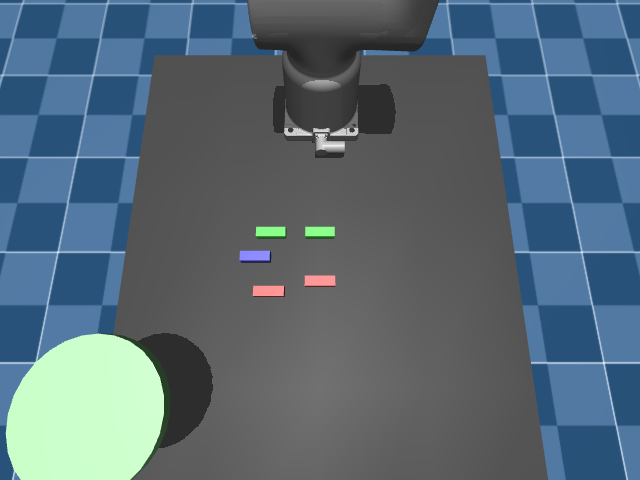

In [2]:
import os
# Set render to EGL
os.environ['MUJOCO_GL'] = 'egl'

import mujoco
import mujoco.viewer
import mediapy as media

# Clone the model repository
!rm -r GoFa_MuJoCo_sim/
!git clone https://github.com/artuurog/GoFa_MuJoCo_sim.git

xml_path = "GoFa_MuJoCo_sim/gofa/scene.xml"

# Load model
model = mujoco.MjModel.from_xml_path(xml_path)
data = mujoco.MjData(model)

# Render scene
with mujoco.Renderer(model, 480, 640) as renderer:
  mujoco.mj_forward(model, data)
  renderer.update_scene(data, camera="external_camera")
  pixels = renderer.render()
  media.show_image(pixels)

## Move the robot giving commands to the joints and render the scene again

In [11]:
import numpy as np
import mediapy as media

#Levenberg-Marquardt method
class LevenbegMarquardtIK:

    def __init__(self, model, data, step_size, tol, alpha, jacp, jacr, damping):
        self.model = model
        self.data = data
        self.step_size = step_size
        self.tol = tol
        self.alpha = alpha
        self.jacp = jacp
        self.jacr = jacr
        self.damping = damping

    def check_joint_limits(self, q):
        """Check if the joints are under or above their limits"""
        for i in range(len(q)):
            q[i] = max(self.model.jnt_range[i][0],
                       min(q[i], self.model.jnt_range[i][1]))

    #Levenberg-Marquardt pseudocode implementation
    def calculate(self, goal, init_q, body_id):
        """Calculate the desired joints angles for goal"""
        self.data.qpos = init_q
        mujoco.mj_forward(self.model, self.data)
        current_pose = self.data.site(body_id).xpos
        error = np.subtract(goal, current_pose)

        # n_iter = 0

        while (np.linalg.norm(error) >= self.tol):
            #calculate jacobian
            mujoco.mj_jacSite(self.model, self.data, self.jacp, self.jacr, body_id)

            #calculate delta of joint q
            n = self.jacp.shape[1]
            I = np.identity(n)
            product = self.jacp.T @ self.jacp + self.damping * I

            if np.isclose(np.linalg.det(product), 0):
                j_inv = np.linalg.pinv(product) @ self.jacp.T
            else:
                j_inv = np.linalg.inv(product) @ self.jacp.T

            delta_q = j_inv @ error
            #compute next step
            self.data.qpos += self.step_size * delta_q

            #check limits
            self.check_joint_limits(self.data.qpos)

            #compute forward kinematics
            mujoco.mj_forward(self.model, self.data)
            #calculate new error
            error = np.subtract(goal, self.data.site(body_id).xpos)

            # print(f"{n_iter} {error} {current_pose}")
            # n_iter += 1

Example usage of the Levenberg-Marquardt inverse kinematics solver

Results
Goal point => [0.5, 0.1, 0.2]
Levenberg-Marquardt result => [0.49973185 0.0998412  0.20052586] 



Initial,Levenberg-Marquardt result

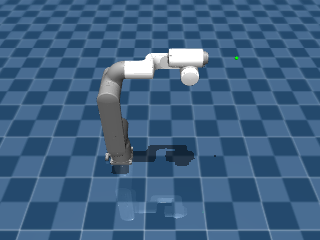
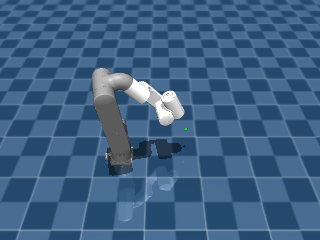

In [21]:
xml_path = "GoFa_MuJoCo_sim/gofa/robot_no_gripper.xml"
model = mujoco.MjModel.from_xml_path(xml_path)
data = mujoco.MjData(model)
renderer = mujoco.Renderer(model)

# Add external camera
camera = mujoco.MjvCamera()
mujoco.mjv_defaultFreeCamera(model, camera)
camera.distance = 2

#Reset state and time
mujoco.mj_resetData(model, data)

#Init variables.
body_id = model.site('ee_site').id
jacp = np.zeros((3, model.nv)) #translation jacobian
jacr = np.zeros((3, model.nv)) #rotational jacobian
goal = [0.5, 0.10, 0.2]

# Parameters for the IK solver
step_size = 0.5
tol = 0.001
alpha = 0.5
init_q = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
damping = 0.01

ik = LevenbegMarquardtIK(model, data, step_size, tol, alpha, jacp, jacr, damping)

# Compute inverse kinematics
mujoco.mj_resetDataKeyframe(model, data, 1) #reset qpos to initial value
ik.calculate(goal, init_q, body_id) #calculate the qpos
result = data.qpos.copy()

#Plot results
print("Results")
data.qpos = init_q
mujoco.mj_forward(model, data)
renderer.update_scene(data, camera)
target_plot = renderer.render()

data.qpos = result
mujoco.mj_forward(model, data)
result_point = data.site('ee_site').xpos
renderer.update_scene(data, camera)
result_plot = renderer.render()

print("Goal point =>", goal)
print("Levenberg-Marquardt result =>", result_point, "\n")

images = {
    'Initial': target_plot,
    'Levenberg-Marquardt result': result_plot,
}

media.show_images(images)

## Simulate and render video

In [57]:
def check_joint_limits(q):
    """Check if the joints is under or above its limits"""
    for i in range(len(q)):
        q[i] = max(model.jnt_range[i][0], min(q[i], model.jnt_range[i][1]))

def circle(t: float, r: float, h: float, k: float, f: float) -> np.ndarray:
    """Return the (x, y) coordinates of a circle with radius r centered at (h, k)
    as a function of time t and frequency f."""
    x = r * np.cos(2 * np.pi * f * t) + h
    y = r * np.sin(2 * np.pi * f * t) + k
    z = 0.6
    return np.array([x, y, z])

xml_path = "GoFa_MuJoCo_sim/gofa/robot_no_gripper.xml"
model = mujoco.MjModel.from_xml_path(xml_path)
data = mujoco.MjData(model)
renderer = mujoco.Renderer(model)

#Video Setup
DURATION = 20 #(seconds)
FRAMERATE = 10 #(Hz)
frames = []

#Reset state and time.
mujoco.mj_resetData(model, data)

#Init position.
# pi = np.pi
# data.qpos = [3*pi/2, -pi/2, pi/2, 3*pi/2, 3*pi/2, 0] #ENABLE if you want test circle

#Init parameters
jacp = np.zeros((3, model.nv)) #translation jacobian
jacr = np.zeros((3, model.nv)) #rotational jacobian
step_size = 0.5
tol = 0.001
damping = 0.1

#Get error.
end_effector_id = model.site('ee_site').id #"End-effector we wish to control.
current_pose = data.site(end_effector_id).xpos #Current pose

# goal = [0.49, 0.13, 0.59] #Desire position

error = np.subtract(goal, current_pose) #Init Error

#Simulate
while data.time < DURATION:

  goal = circle(data.time, 0.2, 0.5, 0.0, 0.05) #ENABLE to test circle.

  if (np.linalg.norm(error) >= tol):
      #Calculate jacobian
      mujoco.mj_jacSite(model, data, jacp, jacr, body_id)
      #Calculate delta of joint q
      n = jacp.shape[1]
      I = np.identity(n)
      product = jacp.T @ jacp + damping * I

      if np.isclose(np.linalg.det(product), 0):
          j_inv = np.linalg.pinv(product) @ jacp.T
      else:
          j_inv = np.linalg.inv(product) @ jacp.T

      delta_q = j_inv @ error

      #Compute next step
      q = data.qpos.copy()
      q += step_size * delta_q

      #Check limits
      check_joint_limits(data.qpos)

      #Set control signal
      data.ctrl = q
      #Step the simulation.
      mujoco.mj_step(model, data)

      error = np.subtract(goal, data.site(end_effector_id).xpos)

  #Render and save frames.
  if len(frames) < data.time * FRAMERATE:
      renderer.update_scene(data)
      pixels = renderer.render()
      frames.append(pixels)
      print(f"{len(frames)}/{DURATION * FRAMERATE}")

  # data.time += 0.2
#Display video.
media.show_video(frames, fps=FRAMERATE)

1/100
2/100
3/100
4/100
5/100
6/100
7/100
8/100
9/100
10/100
11/100
12/100
13/100
14/100
15/100
16/100
17/100
18/100
19/100
20/100
21/100
22/100
23/100
24/100
25/100
26/100
27/100
28/100
29/100
30/100
31/100
32/100
33/100
34/100
35/100
36/100
37/100
38/100
39/100
40/100
41/100
42/100
43/100
44/100
45/100
46/100
47/100
48/100
49/100
50/100
51/100
52/100
53/100
54/100
55/100
56/100
57/100
58/100
59/100
60/100
61/100
62/100
63/100
64/100
65/100
66/100
67/100
68/100
69/100
70/100
71/100
72/100
73/100
74/100
75/100
76/100
77/100
78/100
79/100
80/100
81/100
82/100
83/100
84/100
85/100
86/100
87/100
88/100
89/100
90/100
91/100
92/100
93/100
94/100
95/100
96/100
97/100
98/100
99/100
100/100
101/100


This browser does not support the video tag.


# Use the Vision Language Model in MuJoCo

""

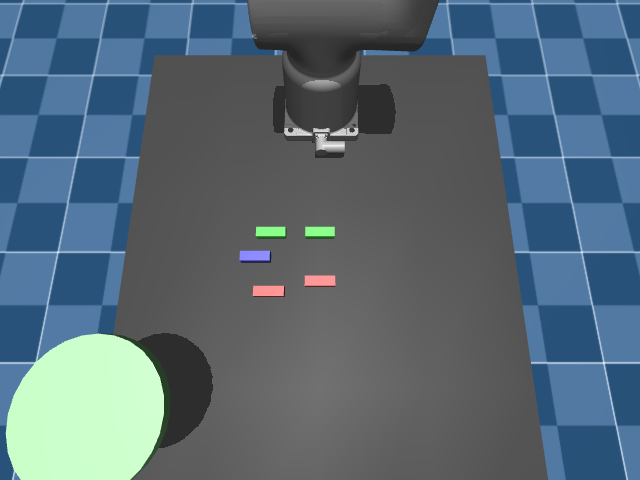

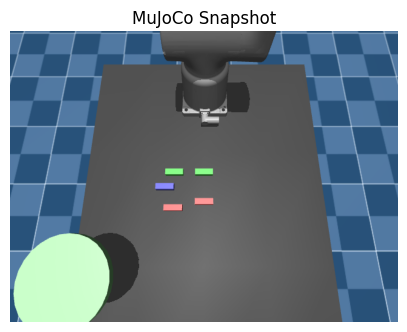

1. Robot configuration:
The robot consists of a gray cylinder connected to a larger gray cylinder. It's mounted on a flat gray surface, likely a table or workbench.

2. Objects in the scene:
- Blue and light blue checkered floor
- Gray rectangular table
- Two green rectangular blocks
- One purple rectangular block
- Two pink rectangular blocks
- Large green circular object

3. Possible pick-and-place action:
The robotic arm could be programmed to pick up one of the colored rectangular blocks and place it in a designated area on the table, such as the center or one of the corners.

4. Pixel coordinates of the green rectangular block:
Top green block: (457 483)
Bottom green block: (504 482)

5. Pixel coordinates of the large green circle:
(049 923)


In [ ]:
import imageio

# ==========================================
# Render offscreen image
# ==========================================

with mujoco.Renderer(model, 480, 640) as renderer:
  mujoco.mj_forward(model, data)
  renderer.update_scene(data, camera="external_camera")
  pixels = renderer.render()
  media.show_image(pixels)

image_path = "mujoco_snapshot.png"
imageio.imwrite(image_path, pixels)

# Display the captured image
plt.figure(figsize=(5,5))
plt.imshow(pixels)
plt.axis("off")
plt.title("MuJoCo Snapshot")
plt.show()

# ==========================================
# Send MuJoCo image to Vision-Language Model
# ==========================================

prompt = """
You are controlling a robotic arm.
Based on this image, describe:
1. The robot configuration
2. The objects in the scene
3. A possible pick-and-place action
4. point to the pixel coordinates of the green rectangular block
5. Point to the large green circle in pixel coordinates
"""

encoded_image = encode_image("mujoco_snapshot.png")

completion = client.chat.completions.create(
    model="allenai/Molmo2-8B",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": f"{prompt}"
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{encoded_image}"
                    }
                }
            ]
        }
    ],
)

print(completion.choices[0].message.content)
